[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

 $$ \bar{x} { = (maiz_{kg} , soya_{kg}, ... , salvado_{kg}) } $$

**Funcion objetivo:**

$$ min \ f(\bar{x}) = precio_{\$} $$

**Restricciones:**

$$\begin{aligned}
& \\ \sum_{\bar{x}}energía_{ingrediente} \ge 25_{Mcal}
& \\ \sum_{\bar{x}}proteína_{ingrediente} \ge 1000_{gr}
& \\ \sum_{\bar{x}}calcio_{ingrediente} \ge 30{gr}
& \\ \sum_{\bar{x}}fósforo_{ingrediente} \ge 20{gr}
& \\ 12_{kg} \ge \sum_{\bar{x}}ingrediente_{kg} \ge 8_{kg}
\end{aligned}$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Programación lineal o simplex

**Justificacion (2-3 oraciones):**
Tenemos: un objetivo lineal, restricciones lineales, variables continuas.

In [128]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [129]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    costo_tot = 0
    k = 0
    for i in x:
         precio = costos_p1[k]
         costo_tot = costo_tot + (i*k)
         k=k+1
    return costo_tot
#también se podía con producto punto lol

def verificar_p1(x):
    nutrientes_totales = nutrientes_p1 @ x #producto punto en numpy
    intake_total = float(x.sum())
    
    nutrientes_ok = np.all(nutrientes_totales >= req_min_p1)
    intake_ok = intake_min_p1 <= intake_total <= intake_max_p1
    bounds_ok = np.all(x >= 0) and np.all(x <= max_kg_p1)
    
    return {
        'factible': bool(nutrientes_ok and intake_ok and bounds_ok),
        'nutrientes_totales': nutrientes_totales,
        'intake_total': intake_total,
    }

def resolver_p1():
	ones = np.ones((1, 6))
	A_ub = np.vstack([-nutrientes_p1,ones,-ones])
	b_ub = np.concatenate([-req_min_p1, [intake_max_p1], [-intake_min_p1]])
	bounds = [(0, m) for m in max_kg_p1] 
	res = linprog(costos_p1, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
	return res.x, float(res.fun)


Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kilogramos
Factible: True


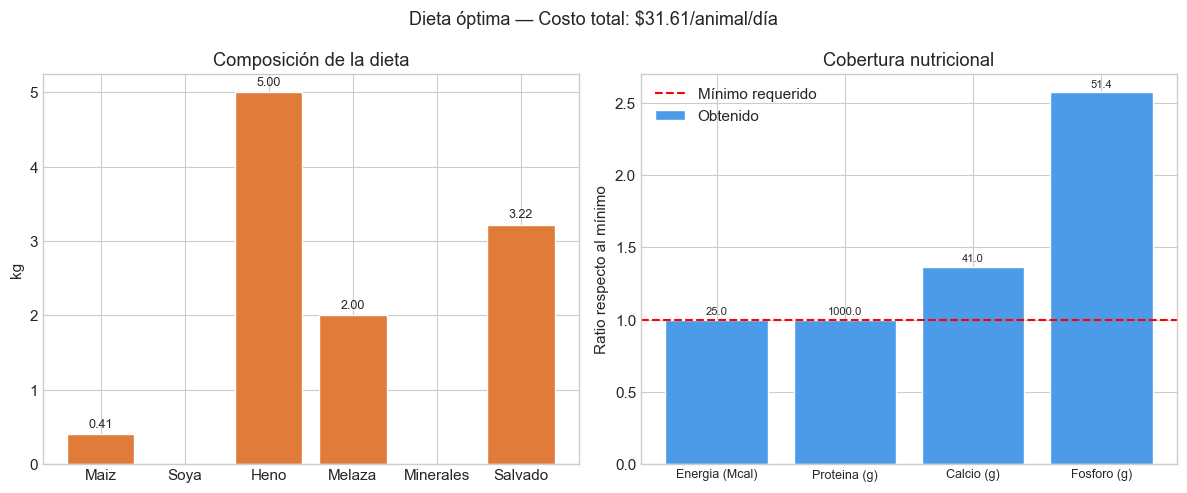

In [130]:
def plot_p1(x_opt, costo_opt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Dieta óptima — Costo total: ${costo_opt:.2f}/animal/día", fontsize=13)
    
	#kilos por ingrediente
    colores = ['#e07b39' if x > 0.001 else '#d0d0d0' for x in x_opt]
    bars = ax1.bar(nombres_p1, x_opt, color=colores, edgecolor='white')
    ax1.set_ylabel("kg")
    ax1.set_title("Composición de la dieta")
    for bar, val in zip(bars, x_opt):
        if val > 0.001:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f"{val:.2f}", ha='center', va='bottom', fontsize=9)
    
    info = verificar_p1(x_opt)
    nutrientes_pct = info['nutrientes_totales'] / req_min_p1  # ratio sobre el mínimo
    
    x_pos = np.arange(len(nombres_nutrientes_p1))
    ax2.bar(x_pos, nutrientes_pct, color='#4c9be8', edgecolor='white', label='Obtenido')
    ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Mínimo requerido')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(nombres_nutrientes_p1, fontsize=9)
    ax2.set_ylabel("Ratio respecto al mínimo")
    ax2.set_title("Cobertura nutricional")
    ax2.legend()
    
    # Anotar valores absolutos
    for i, (ratio, total) in enumerate(zip(nutrientes_pct, info['nutrientes_totales'])):
        ax2.text(i, ratio + 0.02, f"{total:.1f}", ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()


# === EJECUTAR ===
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kilogramos")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

**Variables de decision:**

$$w = (w_1, w_2, w_3, w_4, w_5) \quad w_i \in [0, 0.4]$$

$w_i$ es la fracción del capital invertida en el activo $i$.

**Funcion objetivo:**

$$\min_{w}\; \sigma^2_p = w^\top \Sigma\, w$$

$\Sigma$ es la matriz de covarianzas de los activos.

**Restricciones:**

$$\begin{aligned}
& \sum_{i=1}^{5} w_i = 1 \\
& \sum_{i=1}^{5} r_i\, w_i \ge 0.08 \\
& 0 \le w_i \le 0.40 \quad \forall i
\end{aligned}$$

### 2.2 Eleccion de optimizador

**Optimizador elegido:** minimize 

**Justificacion:** La función objetivo $w^\top \Sigma w$ es cuadrática (no lineal), lo que descarta linprog. Las restricciones son lineales de igualdad y desigfualdad, entonecs min. es el indicado

In [131]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [132]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    return float(w @ cov_p2 @ w)   # varianza


def verificar_p2(w):
    rendimiento = float(rendimientos_p2 @ w)
    varianza    = float(w @ cov_p2 @ w)
    suma_pesos  = float(w.sum())

    return {
        'factible':    (rendimiento >= retorno_minimo_p2 - 1e-6
                        and abs(suma_pesos - 1) < 1e-6
                        and np.all(w >= -1e-6)
                        and np.all(w <= max_por_activo_p2 + 1e-6)),
        'rendimiento': rendimiento,
        'varianza':    varianza,
        'suma_pesos':  suma_pesos,
    }


def resolver_p2():
    n = len(rendimientos_p2)
    w0 = np.ones(n) / n 

    constraints = [
        {'type': 'eq',   'fun': lambda w: w.sum() - 1},
        {'type': 'ineq', 'fun': lambda w: rendimientos_p2 @ w - retorno_minimo_p2},
    ]
    bounds = [(0, max_por_activo_p2)] * n

    res = minimize(objetivo_p2, w0,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})

    if not res.success:
        raise ValueError(f"Optimización fallida: {res.message}")

    return res.x, float(res.fun)


Solucion P2:
  Bonos gob.: 32.6%
  Acciones tech: 0.0%
  Bienes raices: 35.9%
  Materias primas: 17.9%
  Mercados emergentes: 13.6%
Rendimiento esperado: 8.00%
Varianza: 0.001471
Desv. estandar: 3.84%
Factible: True


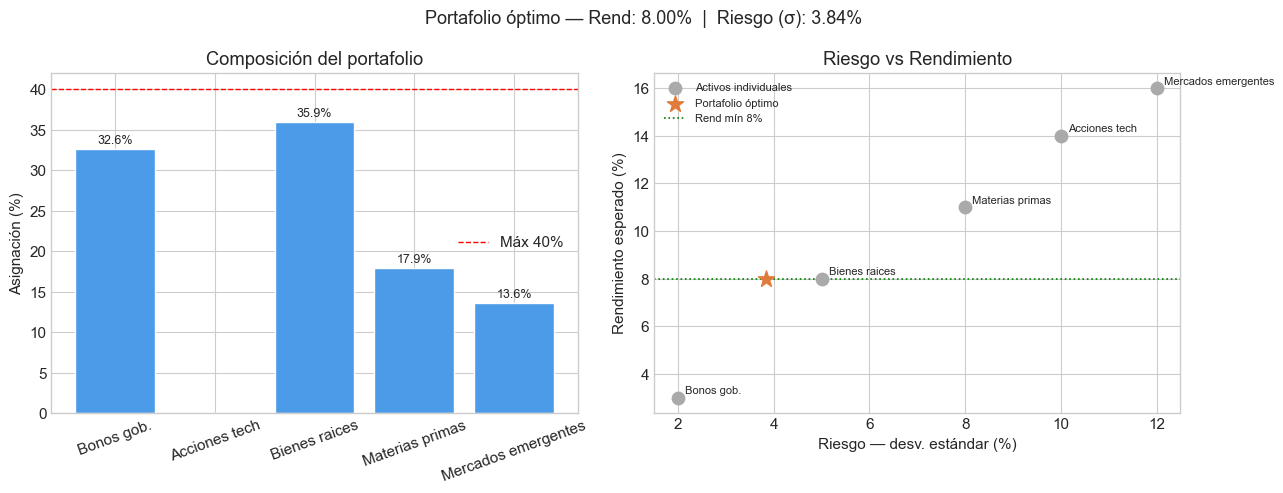

In [133]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    rendimiento_opt = float(rendimientos_p2 @ w_opt)
    std_opt = np.sqrt(varianza_opt)
    fig.suptitle(f"Portafolio óptimo — Rend: {rendimiento_opt*100:.2f}%  |  Riesgo (σ): {std_opt*100:.2f}%", fontsize=13)

    colores = ['#4c9be8' if w > 0.001 else '#d0d0d0' for w in w_opt]
    bars = ax1.bar(activos_p2, w_opt * 100, color=colores, edgecolor='white')
    ax1.axhline(max_por_activo_p2 * 100, color='red', linestyle='--', linewidth=1, label=f'Máx {max_por_activo_p2*100:.0f}%')
    ax1.set_ylabel("Asignación (%)")
    ax1.set_title("Composición del portafolio")
    ax1.legend()
    for bar, val in zip(bars, w_opt):
        if val > 0.001:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val*100:.1f}%", ha='center', va='bottom', fontsize=9)
    ax1.tick_params(axis='x', rotation=20)
    stds_activos = np.sqrt(np.diag(cov_p2))
    ax2.scatter(stds_activos * 100, rendimientos_p2 * 100,
                s=80, color='#aaa', zorder=3, label='Activos individuales')
    for i, nombre in enumerate(activos_p2):
        ax2.annotate(nombre, (stds_activos[i]*100, rendimientos_p2[i]*100),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
    ax2.scatter([std_opt * 100], [rendimiento_opt * 100],
                s=150, color='#e07b39', zorder=5, marker='*', label='Portafolio óptimo')
    ax2.axhline(retorno_minimo_p2 * 100, color='green', linestyle=':', linewidth=1.2, label=f'Rend mín {retorno_minimo_p2*100:.0f}%')
    ax2.set_xlabel("Riesgo — desv. estándar (%)")
    ax2.set_ylabel("Rendimiento esperado (%)")
    ax2.set_title("Riesgo vs Rendimiento")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print("Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)


---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

**Variables de decision:**

$$y = (y_1, \dots, y_7) \quad y_i \in \{0, 1\}$$

donde $y_i = 1$ indica que se construye la torre $i$.

**Funcion objetivo:**

$$\min_{y}\; \sum_{i=1}^{7} c_i\, y_i$$

**Restricciones:**

$$\begin{aligned}
& \sum_{i=1}^{7} A_{ij}\, y_i \ge 1 \quad \forall j = 1,\dots,10 \quad \text{(cada zona cubierta al menos una vez)}\\
& y_i \in \{0, 1\}
\end{aligned}$$

donde $A_{ij} = 1$ si la torre $i$ cubre la zona $j$.

### 3.2 Eleccion de optimizador

**Optimizador elegido:** milp

**Justificacion:** Las variables de decisión son binarias, lo que hace que esto sea un problema de programación entera mixta (MIP). Usamos milp de scipy para tener una solución óptima global con variables que pertenezcan a $\mathbb{Z}$.

In [134]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [135]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    return float(costos_torres_p3 @ y)


def verificar_p3(y):
    cobertura = cobertura_p3.T @ y
    cubiertas    = [j+1 for j in range(n_zonas_p3) if cobertura[j] >= 1]
    sin_cubrir   = [j+1 for j in range(n_zonas_p3) if cobertura[j] < 1]
    return {
        'factible':        len(sin_cubrir) == 0,
        'zonas_cubiertas': cubiertas,
        'zonas_sin_cubrir':sin_cubrir,
    }


def resolver_p3():

    n = n_torres_p3   
    A = cobertura_p3.T.astype(float)
    constraint = LinearConstraint(A, lb=1, ub=np.inf)

    bounds = Bounds(lb=0, ub=1)
    integrality = np.ones(n)

    res = milp(
        c=costos_torres_p3.astype(float),
        constraints=constraint,
        integrality=integrality,
        bounds=bounds,
    )

    if not res.success:
        raise ValueError(f"MILP fallido: {res.message}")

    y_opt = np.round(res.x).astype(int)
    return y_opt, float(res.fun)


Solucion P3:
  T2: Construir (costo=$80k, cubrr las zonas: [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubrr las zonas: [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubrr las zonas: [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


/var/folders/tm/xbxshrb90fjgngzr83cmqt4w0000gn/T/ipykernel_34706/630016836.py:31: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dreincognito/Projects/IA_casio/estudiantes/casiopeosis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


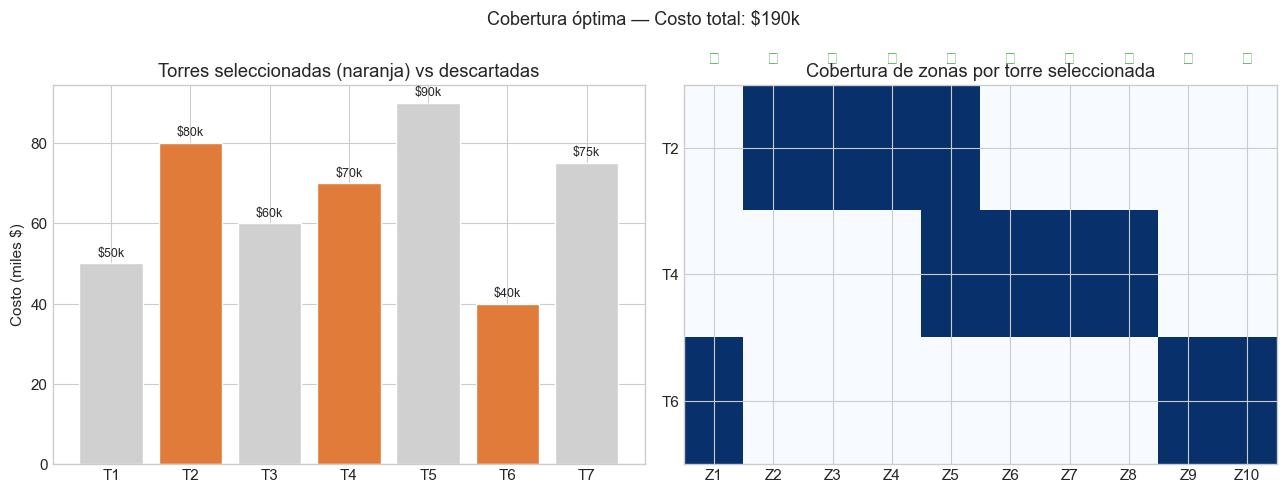

In [136]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    torres_sel = [i for i, y in enumerate(y_opt) if y > 0.5]
    n_sel = len(torres_sel)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Cobertura óptima — Costo total: ${costo_opt:.0f}k", fontsize=13)

    colores = ['#e07b39' if y > 0.5 else '#d0d0d0' for y in y_opt]
    bars = ax1.bar(nombres_torres_p3, costos_torres_p3, color=colores, edgecolor='white')
    ax1.set_ylabel("Costo (miles $)")
    ax1.set_title("Torres seleccionadas (naranja) vs descartadas")
    for bar, sel, costo in zip(bars, y_opt, costos_torres_p3):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"${costo}k", ha='center', va='bottom', fontsize=9)

    mat = cobertura_p3[torres_sel, :]   # (sel, 10)
    im = ax2.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax2.set_xticks(range(n_zonas_p3))
    ax2.set_xticklabels([f"Z{j+1}" for j in range(n_zonas_p3)])
    ax2.set_yticks(range(n_sel))
    ax2.set_yticklabels([nombres_torres_p3[i] for i in torres_sel])
    ax2.set_title("Cobertura de zonas por torre seleccionada")
    cob_total = cobertura_p3.T @ y_opt
    for j in range(n_zonas_p3):
        color_txt = 'green' if cob_total[j] >= 1 else 'red'
        ax2.text(j, -0.7, '✓' if cob_total[j] >= 1 else '✗',
                 ha='center', va='center', color=color_txt, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print("Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubrr las zonas: {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)


---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

**Variables de decision:**

$$x = (a, b, c, d)$$

donde $a$ es amplitud, $b$ frecuencia angular, $c$ fase, $d$ amplitud de decaimiento.

**Funcion objetivo:**

$$\min\; \text{SSE}(x) = \sum_{k=1}^{20} \left[y_k - {y}(t_k,\, x)\right]^2$$

con ${y}(t, x) = a\sin(bt + c) + d\,e^{-0.1t}$.

**Restricciones (bounds):**

$$\begin{aligned}
& a \in [0,\, 5],\quad b \in [0,\, 10],\quad c \in [0,\, 2\pi],\quad d \in [-3,\, 3]
\end{aligned}$$

el problema es no lineal con múltiples mínimos locales

### 4.2 Eleccion de optimizador

**Optimizador elegido:** differential_evolution / dual annealling

**Justificacion:** El problema tiene últiples mínimos locales por el seno. Un optimizador local como minimize se va a quedar atrapado dependiendo del punto inicial. differential_evolution es una nos permite lidiar con una funcion no convexa y escoger puntos importantes entre varios candidatos posibles.

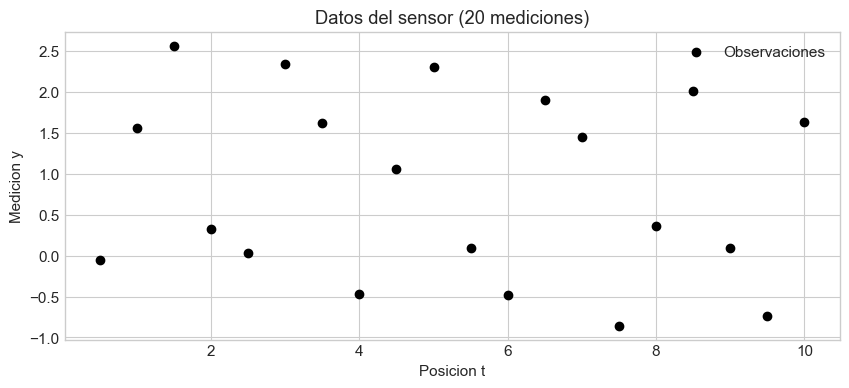

In [137]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [138]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    y_pred = modelo_sensor(t_obs_p4, params)
    return float(np.sum((y_obs_p4 - y_pred) ** 2))


def resolver_p4():
    res = differential_evolution(
        objetivo_p4,
        bounds=bounds_p4,
        seed=42,
        maxiter=2000,
        tol=1e-10,
        mutation=(0.5, 1.5),
        recombination=0.9,
        popsize=20,
        polish=True,
    )
    return res.x, float(res.fun)


Solucion P4:
  a = 1.5090
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


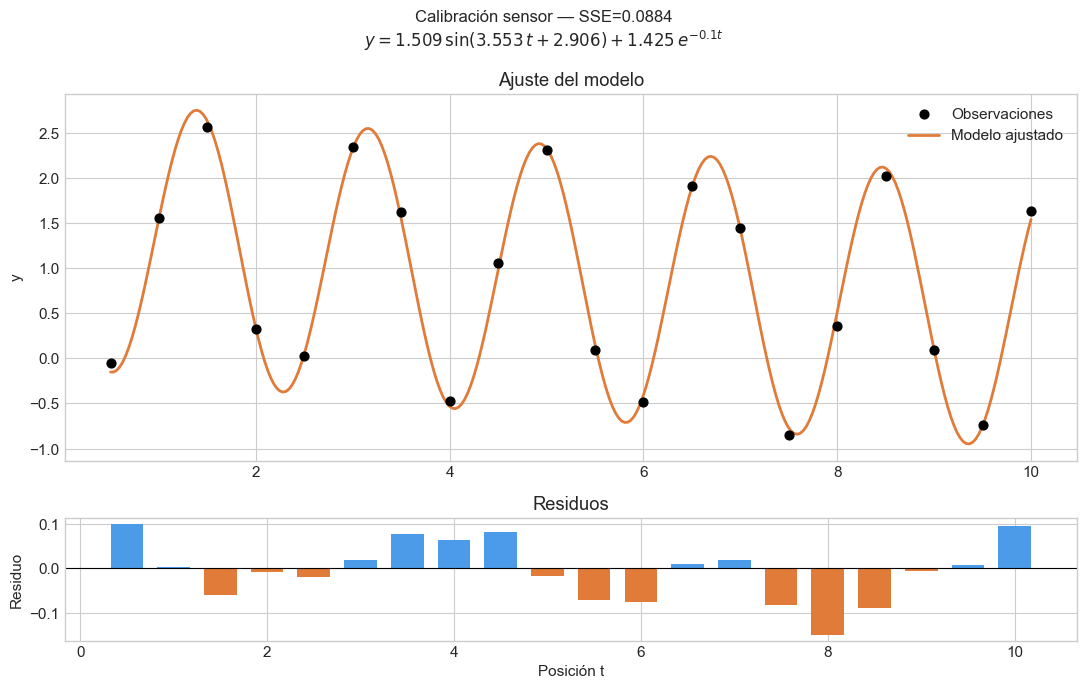

In [139]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    t_fine = np.linspace(t_obs_p4.min(), t_obs_p4.max(), 300)
    y_fit  = modelo_sensor(t_fine, params_opt)
    y_pred = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7),
                                    gridspec_kw={'height_ratios': [3, 1]})
    a, b, c, d = params_opt
    fig.suptitle(f"Calibración sensor — SSE={error_opt:.4f}\n"
                 f"$y = {a:.3f}\\,\\sin({b:.3f}\\,t + {c:.3f}) + {d:.3f}\\,e^{{-0.1t}}$",
                 fontsize=12)

    # Ajuste
    ax1.scatter(t_obs_p4, y_obs_p4, color='black', zorder=5, label='Observaciones', s=40)
    ax1.plot(t_fine, y_fit, color='#e07b39', linewidth=2, label='Modelo ajustado')
    ax1.set_ylabel("y"); ax1.legend(); ax1.set_title("Ajuste del modelo")

    # Residuos
    ax2.bar(t_obs_p4, residuos, width=0.35, color=['#4c9be8' if r >= 0 else '#e07b39' for r in residuos])
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel("Posición t"); ax2.set_ylabel("Residuo"); ax2.set_title("Residuos")

    plt.tight_layout()
    plt.show()
#pregunta : cuándo es que ya no se considera overfit?

params_opt_p4, error_opt_p4 = resolver_p4()

print("Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)


---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

**Variables de decision:**

$$y_i \in \{0,1\} \quad i=1,\dots,4 \quad \text{(abrir CD } i\text{)}$$
$$x_{ij} \ge 0 \quad i=1,\dots,4,\; j=1,\dots,6 \quad \text{(unidades enviadas de CD } i \text{ a cliente } j\text{)}$$

**Funcion objetivo:**

$$\min_{y, X}\; \sum_{i} f_i\, y_i + \sum_{i}\sum_{j} c_{ij}\, x_{ij}$$

donde $f_i$ es el costo fijo del CD $i$ y $c_{ij}$ el costo de envío por unidad.

**Restricciones:**

$$\begin{aligned}
& \sum_{i} x_{ij} = d_j \quad \forall j \quad \text{(demanda satisfecha)} \\
& \sum_{j} x_{ij} \le \text{cap}_i\, y_i \quad \forall i \quad \text{(capacidad y apertura)} \\
& x_{ij} \ge 0,\quad y_i \in \{0,1\}
\end{aligned}$$

### 5.2 Eleccion de optimizador

**Optimizador elegido:** milp

**Justificacion:** El problema mezcla variables binarias yi con variables continuas xi (Mixed Integer Linear Programming). Tanto el objetivo como todas las restricciones son lineales, así que milp resuelve esto. Es el único optimizador del conjunto que maneja simultáneamente integrality y linealidad.

In [140]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    return float(costos_fijos_p5 @ y + (costos_envio_p5 * X).sum())


def verificar_p5(y, X):
    demanda_cumplida  = X.sum(axis=0)          # (6,) suma por columna
    capacidad_usada   = X.sum(axis=1)          # (4,) suma por fila

    demanda_ok    = np.all(np.abs(demanda_cumplida - demandas_p5) < 1e-3)
    capacidad_ok  = np.all(capacidad_usada <= capacidades_p5 * y + 1e-3)
    no_envio_cerr = np.all(X >= -1e-6)

    return {
        'factible':         bool(demanda_ok and capacidad_ok and no_envio_cerr),
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada':  capacidad_usada,
    }


def resolver_p5():

    n_y = n_cds_p5      
    n_x = n_cds_p5 * n_clientes_p5 
    N   = n_y + n_x     

   
    c_vec = np.zeros(N)
    c_vec[:n_y] = costos_fijos_p5
    c_vec[n_y:] = costos_envio_p5.flatten()

   
    A_rows, b_lo, b_hi = [], [], []


    for j in range(n_clientes_p5):
        row = np.zeros(N)
        for i in range(n_cds_p5):
            row[n_y + i * n_clientes_p5 + j] = 1.0
        A_rows.append(row)
        b_lo.append(demandas_p5[j])
        b_hi.append(demandas_p5[j])

    
    for i in range(n_cds_p5):
        row = np.zeros(N)
        row[i] = -capacidades_p5[i]            
        for j in range(n_clientes_p5):
            row[n_y + i * n_clientes_p5 + j] = 1.0  
        A_rows.append(row)
        b_lo.append(-np.inf)
        b_hi.append(0.0)

    A = np.array(A_rows)
    constraint = LinearConstraint(A, lb=b_lo, ub=b_hi)


    lb = np.zeros(N)
    ub = np.full(N, np.inf)
    ub[:n_y] = 1.0                            
    integrality = np.zeros(N)
    integrality[:n_y] = 1

    res = milp(c_vec, constraints=constraint,
               integrality=integrality,
               bounds=Bounds(lb=lb, ub=ub))

    if not res.success:
        raise ValueError(f"MILP fallido: {res.message}")

    y_opt = np.round(res.x[:n_y]).astype(int)
    X_opt = res.x[n_y:].reshape(n_cds_p5, n_clientes_p5)
    return y_opt, X_opt, float(res.fun)


Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


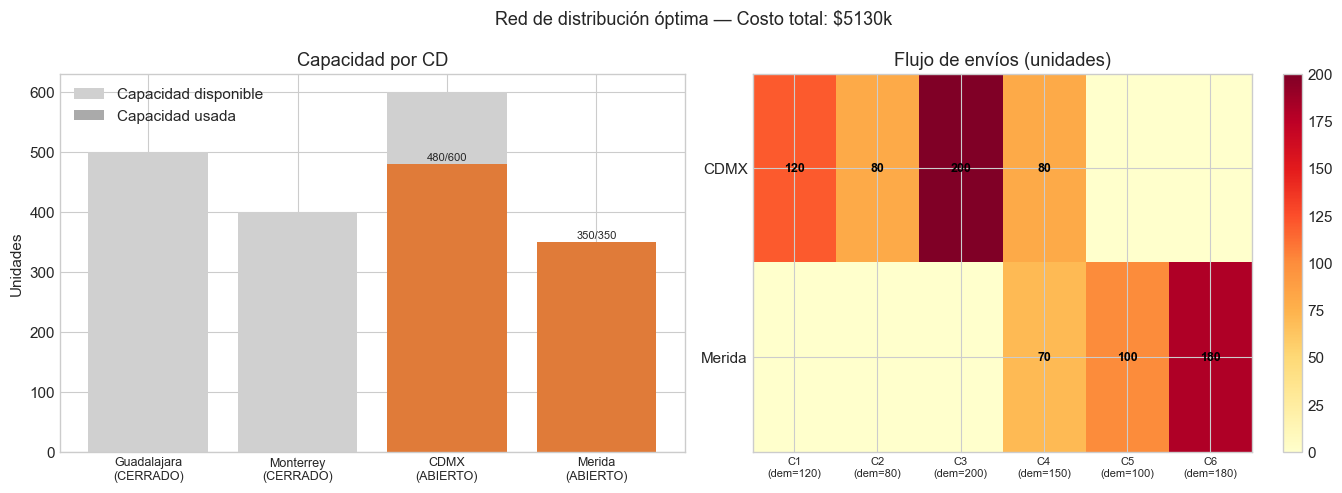

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    info = verificar_p5(y_opt, X_opt)
    cds_abiertos = [i for i, y in enumerate(y_opt) if y > 0.5]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Red de distribución óptima — Costo total: ${costo_opt:.0f}k", fontsize=13)


    labels = [f"{ciudades_p5[i]}\n({'ABIERTO' if y > 0.5 else 'CERRADO'})" for i, y in enumerate(y_opt)]
    usada = info['capacidad_usada']
    disponible = capacidades_p5.astype(float)
    x_pos = np.arange(n_cds_p5)

    ax1.bar(x_pos, disponible, color='#d0d0d0', label='Capacidad disponible')
    ax1.bar(x_pos, usada, color=['#e07b39' if y > 0.5 else '#aaa' for y in y_opt], label='Capacidad usada')
    ax1.set_xticks(x_pos); ax1.set_xticklabels(labels, fontsize=9)
    ax1.set_ylabel("Unidades"); ax1.set_title("Capacidad por CD"); ax1.legend()

    for i, (u, d) in enumerate(zip(usada, disponible)):
        if y_opt[i] > 0.5:
            ax1.text(i, u + 5, f"{u:.0f}/{d:.0f}", ha='center', fontsize=8)

    if cds_abiertos:
        mat = X_opt[cds_abiertos, :]
        im = ax2.imshow(mat, aspect='auto', cmap='YlOrRd')
        ax2.set_xticks(range(n_clientes_p5))
        ax2.set_xticklabels([f"C{j+1}\n(dem={demandas_p5[j]})" for j in range(n_clientes_p5)], fontsize=8)
        ax2.set_yticks(range(len(cds_abiertos)))
        ax2.set_yticklabels([ciudades_p5[i] for i in cds_abiertos])
        ax2.set_title("Flujo de envíos (unidades)")
        plt.colorbar(im, ax=ax2)
        for ii, i in enumerate(cds_abiertos):
            for j in range(n_clientes_p5):
                if X_opt[i, j] > 0.5:
                    ax2.text(j, ii, f"{X_opt[i,j]:.0f}", ha='center', va='center',
                             fontsize=9, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()


y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print("Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)
